# Регуляризация и контроль сложности моделей

**Выполнила:** Смирнова Анастасия

## Настройка окружения

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

# ----------------------------
# Общие настройки
# ----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# Вспомогательные функции
# ----------------------------
def make_synthetic_linear_regression(
    n: int = 600,
    d: int = 20,
    noise_std: float = 0.5,
    sparsity: float = 0.5,
):
    """Синтетическая линейная регрессия: y = X w_true + noise.
    sparsity: доля нулевых компонент в w_true (примерно).
    """
    X = np.random.randn(n, d).astype(np.float32)
    w_true = np.random.randn(d).astype(np.float32)
    # обнулим часть весов для наглядности (L1 должен это «любить»)
    k0 = int(d * sparsity)
    if k0 > 0:
        zero_idx = np.random.choice(d, size=k0, replace=False)
        w_true[zero_idx] = 0.0
    y = X @ w_true + noise_std * np.random.randn(n).astype(np.float32)
    return X, y, w_true

def train_val_test_split(X, y, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    idx = np.random.permutation(n)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), (X[test_idx], y[test_idx])

def mse(pred, target):
    return torch.mean((pred - target) ** 2)

def l2_norm(w: torch.Tensor) -> float:
    return float(torch.norm(w.detach(), p=2).cpu().item())

def sparsity_ratio(w: torch.Tensor, eps: float = 0.01) -> float:
    w_abs = torch.abs(w.detach()).cpu().numpy()
    return float(np.mean(w_abs < eps))

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

# Датасет для задач 2,3,4,5,6,7,9 (один и тот же)
X_np, y_np, w_true_np = make_synthetic_linear_regression(n=800, d=25, noise_std=0.7, sparsity=0.4)
(train_X, train_y), (val_X, val_y), (test_X, test_y) = train_val_test_split(X_np, y_np, 0.6, 0.2)

train_X_t, train_y_t = to_tensor(train_X), to_tensor(train_y).view(-1, 1)
val_X_t, val_y_t     = to_tensor(val_X),   to_tensor(val_y).view(-1, 1)
test_X_t, test_y_t   = to_tensor(test_X),  to_tensor(test_y).view(-1, 1)

w_true_t = to_tensor(w_true_np).view(-1, 1)

print("Shapes:", train_X_t.shape, train_y_t.shape, "| w_true:", w_true_t.shape)

Device: cpu
Shapes: torch.Size([480, 25]) torch.Size([480, 1]) | w_true: torch.Size([25, 1])


---

## Теоретический минимум

### Что такое регуляризация

**Регуляризация** — набор методов для уменьшения переобучения путем добавления ограничений на параметры.

$$\tilde{E}(\mathbf{w}) = E(\mathbf{w}) + \frac{\lambda}{2} \mathbf{w}^T\mathbf{w}$$

### L2-регуляризация (Weight Decay)

$$\Omega(\mathbf{w}) = \frac{\lambda}{2} ||\mathbf{w}||_2^2 = \frac{\lambda}{2} \sum_j w_j^2$$

Градиент: $\nabla \tilde{E}(\mathbf{w}) = \nabla E(\mathbf{w}) + \lambda \mathbf{w}$

### L1-регуляризация (Lasso)

$$\Omega(\mathbf{w}) = \frac{\lambda}{2} ||\mathbf{w}||_1 = \frac{\lambda}{2} \sum_j |w_j|$$

L1 приводит к **разреженным** решениям.

### Early Stopping

Прекращение обучения, когда значение loss на валидации начинает расти. Приблизительно: $\tau \eta \sim 1/\lambda$.

### Dropout

Случайное выключение нейронов с вероятностью $1-\rho$. При инференсе веса эффективно умножаются на $\rho$.

### Residual Connections

$$\mathbf{z}_l = F_l(\mathbf{z}_{l-1}) + \mathbf{z}_{l-1}$$

## Задача 1. L1- и L2-регуляризация вручную

### Постановка задачи

Реализовать две функции, которые по вектору весов $w \in \mathbb{R}^d$ и коэффициенту регуляризации $\lambda$ вычисляют скалярные значения регуляризаторов:
- L1 (Lasso): $\Omega_{L1}(w) = \frac{\lambda}{2} \sum_j |w_j|$;
- L2 (Ridge): $\Omega_{L2}(w) = \frac{\lambda}{2} \sum_j w_j^2$.

Протестировать функции на нескольких векторах весов, сравнить с ручным счетом и прокомментировать, как отличаются численные значения L1 и L2 для одного и того же $w$.

### Теоретический минимум
- Регуляризация добавляет к исходной функции ошибки $E(w)$ штраф: $\tilde{E}(w) = E(w) + \Omega(w)$.
- L2: $\Omega_{L2}(w) = \frac{\lambda}{2}\|w\|_2^2$, градиент по $w$: $\lambda w$.
- L1: $\Omega_{L1}(w) = \frac{\lambda}{2}\|w\|_1$, подградиент по $w_j$: $\lambda\,\text{sign}(w_j)$.
- L1 дает разреженные решения (многие веса точно 0), L2 — сглаживает веса, но почти не обнуляет.

Реализуем функции L1 и L2 регуляризации вручную и проверим как будут меняться значения регуляризаторов с увелиением нормы векторов и значения параметра $\lambda$.

In [ ]:
def compute_l1_regularization(w, lam: float):
    """
    Функция нахождения L1-регуляризатора
    Ω_L1(w) = (λ/2) * sum_j |w_j|

    Параметры:
        w: torch.tensor
            Вектор весов
        lam: float
            Параметр lambda,
            отвечающий за степень регуляризации
    """
    return lam / 2 * torch.sum(torch.abs(w))

In [ ]:
def compute_l2_regularization(w, lam: float):
    """
    Функция нахождения L2-регуляризатора
    Ω_L2(w) = (λ/2) * sum_j w_j^2

    Параметры:
        w: torch.tensor
            Вектор весов
        lam: float
            Параметр lambda,
            отвечающий за степень регуляризации
    """
    return lam / 2 * torch.sum(w ** 2)

Проверку проведем на значениях $\lambda$ = [0.1, 0.4, 0.7] и на векторе $w = [0.2674, 0.5349, 0.8094]$ с его исходной длиной, а также увеличенной в 5 и 10 раз соответственно.

In [ ]:
# Тесты
lam = np.arange(0.1, 1, 0.3)

t_1 = torch.FloatTensor([0.2674, 0.5349, 0.8094])
t_2 = t_1.detach().clone() * 5
t_3 = t_1.detach().clone() * 10

tests = [t_1, t_2, t_3]

for w in tests:
    for l in lam:
        l1_res = compute_l1_regularization(w, l)
        l2_res = compute_l2_regularization(w, l)

        print(f"Вектор: {w}, lambda: {l:.1f}")
        print(f"Результат L1-регуляризации для вектора: {l1_res:.4f}")
        print(f"Результат L2-регуляризации для вектора: {l2_res:.4f}")
        print("-" * 50)

Вектор: tensor([0.2674, 0.5349, 0.8094]), lambda: 0.1
Результат L1-регуляризации для вектора: 0.0806
Результат L2-регуляризации для вектора: 0.0506
--------------------------------------------------
Вектор: tensor([0.2674, 0.5349, 0.8094]), lambda: 0.4
Результат L1-регуляризации для вектора: 0.3223
Результат L2-регуляризации для вектора: 0.2025
--------------------------------------------------
Вектор: tensor([0.2674, 0.5349, 0.8094]), lambda: 0.7
Результат L1-регуляризации для вектора: 0.5641
Результат L2-регуляризации для вектора: 0.3545
--------------------------------------------------
Вектор: tensor([1.3370, 2.6745, 4.0470]), lambda: 0.1
Результат L1-регуляризации для вектора: 0.4029
Результат L2-регуляризации для вектора: 1.2659
--------------------------------------------------
Вектор: tensor([1.3370, 2.6745, 4.0470]), lambda: 0.4
Результат L1-регуляризации для вектора: 1.6117
Результат L2-регуляризации для вектора: 5.0637
--------------------------------------------------
Векто

**Вывод**: для каждой пары с увеличением значения $\lambda$ заметно, что величина L1-регуляризатора демонстрирует линейный рост, в то время как величина L2-регуляризатора увеличивается квадратично.

Для векторов с маленькой нормой значение L2-регуляризатора может быть меньше, чем L1-регуляризатора, так как квадрат маленького числа будет ещё меньшим числом. Однако с увеличением нормы векторов разрыв между величинами регуляризаторов увеличивается и для векторов с большими нормами значение L2-регуляризатора значительно превышает значение L1-регуляризатора.

Таким образом, при применении L2-регуляризации большие значения весов будут сглаживаться, в то время как при применении L1-регуляризации некоторые веса будут стремиться к нулю.

---

## Задача 2. Обучение с L2-регуляризацией

### Постановка задачи

Нужно обучить линейную модель регрессии на синтетическом датасете, добавив к функции потерь L2-регуляризацию. Требуется:
- реализовать обучение модели с различными значениями $\lambda$;
- визуализировать полученные веса (например, столбиковая диаграмма и/или сравнение с истинными весами);
- проанализировать, как величина $\lambda$ влияет на величины весов и качество (MSE на валидации/тесте).

### Теоретический минимум
- Линейная модель: $\hat{y} = Xw$.
- MSE: $E(w) = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$.
- L2-регуляризованный loss: $\tilde{E}(w) = E(w) + \frac{\lambda}{2}\sum_j w_j^2$.
- Градиент: $\nabla_w \tilde{E} = \frac{2}{N} X^T(Xw - y) + \lambda w$.
- Увеличение $\lambda$ уменьшает норму весов, снижая variance и повышая bias.

Создадим модель линеной регрессии, а также функцию для ее обучения с применением L2-регуляризации.

In [ ]:
class LinearRegressor(nn.Module):
    """
    Класс для нахождения линейной регрессии

    Атрибуты:
        self.d: int
            Размер входного слоя
        self.fc: torch.nn.Linear
            Линейный слой с входной размерностью
            d и выходной размерностью 1
    Методы:
        forward()
            Прямой проход через модель
    """

    def __init__(self, d: int):
        super(LinearRegressor, self).__init__()

        self.d = d
        self.fc = torch.nn.Linear(self.d, 1)

    def forward(self, x):
        return self.fc(x)

In [ ]:
def train_linear_with_l2(
    train_X: torch.Tensor,
    train_y: torch.Tensor,
    val_X: torch.Tensor,
    val_y: torch.Tensor,
    test_X: torch.Tensor,
    test_y: torch.Tensor,
    lam: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    """
    Обучает линейную регрессию с применением L2-регуляризации
    в течение заданного количества эпох

    Параметры:
        train_X: torch.Tensor
            Тензор с признаками для обучения
        train_y: torch.Tensor
            Тензор с целевыми значениями для обучения
        val_X: torch.Tensor
            Тензор с признаками для валидации
        val_y: torch.Tensor
            Тензор с целевыми значениями для валидации
        test_X: torch.Tensor
            Тензор с признаками для тестирования
        test_y: torch.Tensor
            Тензор с целевыми значениями для тестирования
        lam: float
            Коэффициент lambda
        lr: float
            Скорость обучения learning_rate
        epochs: int
            Количество эпох, в течение которых обучается модель

    Возвращает:
        weights_calculated: torch.Tensor
            Веса модели
        train_losses: list
            История потерь на обучающей выборке
        val_losses: list
            История потерь на валидационной выборке
        test_loss: float
            Ошибка на тестовой выборке
    """
    train_losses = []
    val_losses = []

    lin_reg = LinearRegressor(train_X.shape[1]).to(device)
    optimizer = optim.SGD(lin_reg.parameters(), lr=lr)

    for epoch in range(epochs):
        lin_reg.train()
        optimizer.zero_grad()
        y_pred = lin_reg(train_X)

        mse_loss = mse(y_pred, train_y)
        l2_reg = compute_l2_regularization(lin_reg.fc.weight, lam)
        loss_func = mse_loss + l2_reg

        loss_func.backward()
        optimizer.step()

        train_losses.append(mse_loss.item())

        # Валидационная выборка
        lin_reg.eval()
        with torch.no_grad():
            val_pred = lin_reg(val_X)
            val_loss = mse(val_pred, val_y)
            val_losses.append(val_loss.item())

    # Тестовая выборка
    lin_reg.eval()
    with torch.no_grad():
        test_pred = lin_reg(test_X)
        test_loss = mse(test_pred, test_y).item()
        weights_calculated = lin_reg.fc.weight.detach().view(-1, 1)

    return weights_calculated, train_losses, val_losses, test_loss

Попробуем обучаться при различных значениях $\lambda$ и оценим, как различные значения будут влиять на веса модели.

In [ ]:
lambdas = [0, 0.01, 0.1, 1.0]
results = {}

for lam in lambdas:
   weights_calculated, train_losses, val_losses, test_loss = train_linear_with_l2(
    train_X_t, train_y_t,
    val_X_t, val_y_t,
    test_X_t, test_y_t,
    lam=lam
)
   results[lam] = {
        'weights': weights_calculated,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_loss': test_loss,
        'l2_norm': torch.norm(weights_calculated).item()
    }

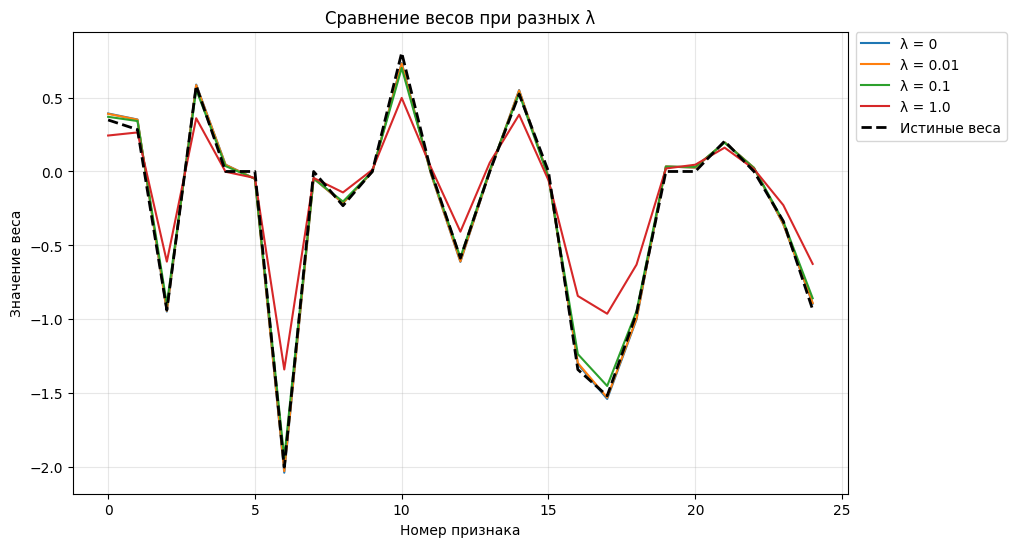

In [ ]:
# Визуализируем веса для разных lambda и сравним с истинными
plt.figure(figsize=(10, 6))

for lam in lambdas:
    plt.plot(results[lam]['weights'].cpu().numpy(), label=f'λ = {lam}')
plt.plot(w_true_t.cpu().numpy(), 'k--', label='Истиные веса', linewidth=2)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.xlabel('Номер признака')
plt.ylabel('Значение веса')
plt.title('Сравнение весов при разных λ')
plt.grid(alpha=0.3)
plt.show()

- При $\lambda = 0$ веса модели близки к истинным, что соответствует отсутствию влияния регуляризации.
- При $\lambda = 0.01$ кривая весов все еще близка к кривой истинных весов, однако уже не в точности повторяет ее. Риск переобучения сохраняется, однако влияние регуляризация на веса уже присутствует.
- При $\lambda = 0.1$ регуляризация становится более заметной. Исходные веса сглаживаются, однако сильно не отдалаяются от исходных. В данном случае можно говорить об умеренной регуляризации;
- При $\lambda = 1$ веса становятся сильно сглаженными и кривая сильно отдаляется от истинных весов. Регуляризация становится очень сильной, модель рискует недообучиться.

Визуализируем динамику изменения `MSE` с увеличением $\lambda$.

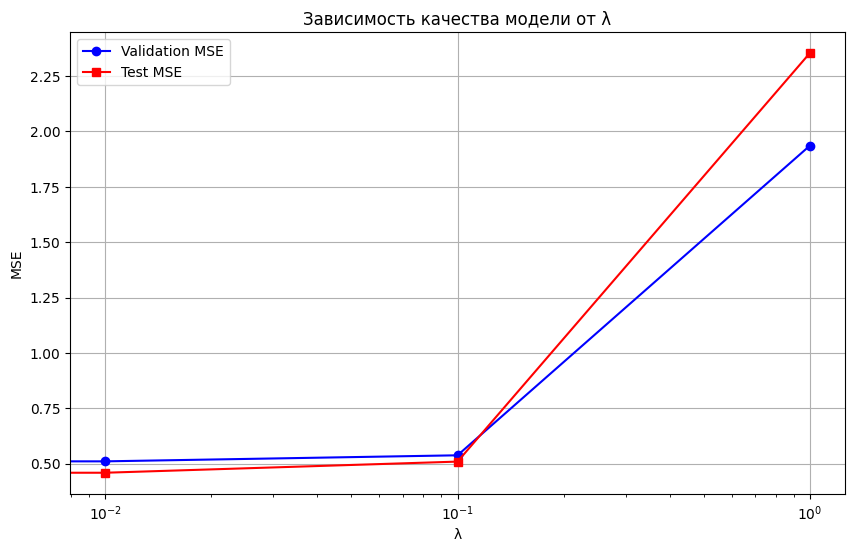

In [ ]:
# Визуализируем динамику изменения loss с увеличением lambda
plt.figure(figsize=(10, 6))

lambdas_sorted = sorted(results.keys())

# Для каждого lambda берем нужные значения
val_mses = [results[lam]['val_losses'][-1] for lam in lambdas_sorted]
test_mses = [results[lam]['test_loss'] for lam in lambdas_sorted]

# Строим графики
plt.xscale('log')

plt.plot(lambdas_sorted, val_mses, 'o-', label='Validation MSE', color='blue')
plt.plot(lambdas_sorted, test_mses, 's-', label='Test MSE', color='red')

plt.xlabel('λ')
plt.ylabel('MSE')
plt.legend()
plt.title('Зависимость качества модели от λ')
plt.grid(True)
plt.show()

График наглядно илюстрирует, что оптимальное значение $\lambda$ при применении L2-регуляризации лежит в диапазоне очень малых значений (<= 0.1). При таких значениях, MSE на тестовой выборке меньше, чем на валидационной. При $\lambda$ > 0.1 MSE на тестовой выборке начинает увеличиваться и при $\lambda = 1$ отчетливо видно недообучение модели.

---

## Задача 3. Weight Decay в оптимизаторе PyTorch

### Постановка задачи

Переписать обучение из задачи 2, используя встроенный параметр `weight_decay` у оптимизатора PyTorch вместо явного добавления L2 в loss. Сравнить результаты (веса и метрики) с задачей 2 и убедиться, что поведение совпадает при одинаковом $\lambda$.

### Теоретический минимум
- В PyTorch L2-регуляризация обычно задается через `weight_decay` в оптимизаторе.
- При `weight_decay = λ` оптимизатор добавляет $\lambda w$ к градиенту параметров, что эквивалентно L2 в функции потерь.
- Нельзя одновременно применять один и тот же L2 и в loss, и в `weight_decay` для тех же параметров (иначе будет двойной штраф).


Посмотрим, какие значения MSE будут получаться при применении встроенного в `optim.SGD` параметра `weight_decay` и сравним со значениями, полученными при применении L2-регуляризации в ручную.

Для этого оптимизируем функцию из задания 2.

In [ ]:
def train_linear_with_weight_decay(
    train_X: torch.Tensor,
    train_y: torch.Tensor,
    val_X: torch.Tensor,
    val_y: torch.Tensor,
    test_X: torch.Tensor,
    test_y: torch.Tensor,
    weight_decay: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    """
    Обучает линейную регрессию с применением L2-регуляризации
    при помощи встроенного в оптимизатор параметра weight_decay
    в течение заданного количества эпох

    Параметры:
        train_X: torch.Tensor
            Тензор с признаками для обучения
        train_y: torch.Tensor
            Тензор с целевыми значениями для обучения
        val_X: torch.Tensor
            Тензор с признаками для валидации
        val_y: torch.Tensor
            Тензор с целевыми значениями для валидации
        test_X: torch.Tensor
            Тензор с признаками для тестирования
        test_y: torch.Tensor
            Тензор с целевыми значениями для тестирования
        weight_decay: float
            Коэффициент lambda для передачи в параметр weight_decay
        lr: float
            Скорость обучения learning_rate
        epochs: int
            Количество эпох, в течение которых обучается модель

    Возвращает:
        weights_calculated: torch.Tensor
            Веса модели
        train_losses: list
            История потерь на обучающей выборке
        val_losses: list
            История потерь на валидационной выборке
        test_loss: float
            Ошибка на тестовой выборке
    """
    lin_reg = LinearRegressor(train_X.shape[1]).to(device)
    optimizer = optim.SGD(lin_reg.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    for _ in range(epochs):
        lin_reg.train()
        optimizer.zero_grad()

        pred = lin_reg(train_X)
        loss = mse(pred, train_y)

        loss.backward()
        optimizer.step()

        lin_reg.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(lin_reg(val_X), val_y).item()))

    with torch.no_grad():
        test_loss = float(mse(lin_reg(test_X), test_y).item())
        weights_calculated = lin_reg.fc.weight.detach().view(-1, 1).clone()

    return weights_calculated, train_losses, val_losses, test_loss

In [ ]:
# Сравнение: явный L2 (из задачи 2) vs weight_decay
compare_lams = [0, 0.01, 0.1, 1.0]
for lam in compare_lams:
    w_l2, _, _, test_l2 = train_linear_with_l2(
        train_X_t, train_y_t,
        val_X_t, val_y_t,
        test_X_t, test_y_t,
        lam=lam,
        lr=0.05,
        epochs=400
    )

    w_wd, _, _, test_wd = train_linear_with_weight_decay(
        train_X_t, train_y_t,
        val_X_t, val_y_t,
        test_X_t, test_y_t,
        weight_decay=lam,
        lr=0.05,
        epochs=400
    )

    diff = float(torch.norm(w_l2 - w_wd).cpu().item())
    print(f"λ={lam:<5} | test_mse L2={test_l2:.4f} | test_mse WD={test_wd:.4f} | ||w_L2 - w_WD||2={diff:.4f}")

λ=0     | test_mse L2=0.4577 | test_mse WD=0.4577 | ||w_L2 - w_WD||2=0.0000
λ=0.01  | test_mse L2=0.4594 | test_mse WD=0.4594 | ||w_L2 - w_WD||2=0.0000
λ=0.1   | test_mse L2=0.5097 | test_mse WD=0.5097 | ||w_L2 - w_WD||2=0.0001
λ=1.0   | test_mse L2=2.3535 | test_mse WD=2.3539 | ||w_L2 - w_WD||2=0.0003


Как видно разница в MSE между двумя методами незначительная и связана с точностью округления. Можно использовать как встроенный в оптимизатор `weight_decay`, так и применять функцию потерь, созданную вручную.

Главное не применять два метода одновременно, иначе будет наложен двойной "штраф".

---

## Задача 4. Early Stopping

### Постановка задачи

Реализовать механизм ранней остановки (Early Stopping), который:
- отслеживает метрику (например, `val_loss`) по эпохам;
- прекращает обучение, если метрика не улучшается более чем на `min_delta` в течение `patience` эпох;
- сохраняет лучшие веса модели (по минимальному `val_loss`).

Интегрировать этот механизм в цикл обучения одной из моделей из предыдущих задач.

### Теоретический минимум
- Early Stopping — форма регуляризации: вместо явного штрафа на веса ограничивается эффективное время обучения.
- Идея: после некоторой эпохи модель начинает переобучаться, и `val_loss` растет.
- Параметры:
  - `patience` — сколько эпох ждать улучшения;
  - `min_delta` — минимальное изменение loss, считаемое улучшением.


Реализуем класс для механизма ранней остановки.

In [ ]:
class EarlyStopping:
    """
    Класс для реализации механизма ранней остановки (Early Stopping).

    Отслеживает значение валидационной ошибки и останавливает обучение,
    если ошибка не улучшается в течение заданного количества эпох (patience).
    Сохраняет веса модели с наилучшим значением ошибки.

    Атрибуты:
        patience: int
            Количество эпох без улучшения, после которого обучение останавливается
        min_delta: float
            Минимальное изменение ошибки, считающееся улучшением. По умолчанию 1e-4
        best_loss: float or None
            Наилучшее значение валидационной ошибки
        counter: int
            Счетчик эпох без улучшения
        best_state: dict or None
            Сохраненное состояние модели с наилучшей ошибкой
        flag: bool
            Флаг, указывающий, нужно ли остановить обучение
    """

    def __init__(self, patience=5, min_delta=1e-4):
        self.best_loss = None
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_state = None
        self.flag = False

    def __call__(self, val_loss, model):
        """
        Вызывается после каждой эпохи обучения.

        Параметры:
            val_loss: float
                Значение функции потерь на валидационной выборке
            model: torch.nn.Module
                Обучаемая модель

        Возвращает:
            None, но обновляет внутреннее состояние класса
            и устанавливает флаг early_stop при необходимости
        """
        if self.best_loss is None:
            # Первая эпоха
            self.best_loss = val_loss
            self.best_state = {}
            for k, v in model.state_dict().items():
                self.best_state[k] = v.detach().clone()
        elif val_loss < self.best_loss - self.min_delta:
            # Значимое улучшение
            self.best_loss = val_loss
            self.best_state = {}
            for k, v in model.state_dict().items():
                self.best_state[k] = v.detach().clone()
            self.counter = 0
        else:
            # Нет улучшения
            self.counter += 1
            if self.counter >= self.patience:
                self.flag = True

Обучим модель с механизмом ранней остановки.

In [ ]:
def train_linear_with_early_stop(
    train_X: torch.Tensor,
    train_y: torch.Tensor,
    val_X: torch.Tensor,
    val_y: torch.Tensor,
    test_X: torch.Tensor,
    test_y: torch.Tensor,
    lr: float = 0.05,
    epochs: int = 800,
    patience: int = 5,
    min_delta: float = 1e-4
):
    """
    Обучает линейную регрессию с применением ранней остановки

    Параметры:
        train_X: torch.Tensor
            Тензор с признаками для обучения
        train_y: torch.Tensor
            Тензор с целевыми значениями для обучения
        val_X: torch.Tensor
            Тензор с признаками для валидации
        val_y: torch.Tensor
            Тензор с целевыми значениями для валидации
        test_X: torch.Tensor
            Тензор с признаками для тестирования
        test_y: torch.Tensor
            Тензор с целевыми значениями для тестирования
        lr: float
            Скорость обучения learning_rate
        epochs: int
            Количество эпох, в течение которых обучается модель
        patience: int
            Количество эпох без улучшения, после которого обучение останавливается
        min_delta: float
            Минимальное изменение ошибки, считающееся улучшением. По умолчанию 1e-4

    Возвращает:
        early_stop_epoch: int or None
            Номер эпохи, на которой сработал механизм ранней остановки,
            или None, если остановка не произошла
        weights_calculated: torch.Tensor
            Веса модели
        train_losses: list
            История потерь на обучающей выборке
        val_losses: list
            История потерь на валидационной выборке
        test_loss: float
            Ошибка на тестовой выборке
    """
    train_losses = []
    val_losses = []
    early_stop_epoch = None

    early_stop_model = LinearRegressor(train_X.shape[1]).to(device)
    optimizer = optim.SGD(early_stop_model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta)

    for epoch in range(epochs):
        early_stop_model.train()
        optimizer.zero_grad()
        y_pred = early_stop_model(train_X)

        mse_loss = mse(y_pred, train_y)

        mse_loss.backward()
        optimizer.step()

        train_losses.append(mse_loss.item())

        # Валидационная выборка
        early_stop_model.eval()
        with torch.no_grad():
            val_pred = early_stop_model(val_X)
            val_loss = mse(val_pred, val_y)
            val_losses.append(val_loss.item())

        early_stopping(val_loss, early_stop_model)
        if early_stopping.flag:
            print(f"Ранняя остановка на {epoch} эпохе")
            early_stop_epoch = epoch
            break

    early_stop_model.load_state_dict(early_stopping.best_state)

    # Тестовая выборка
    early_stop_model.eval()
    with torch.no_grad():
        test_pred = early_stop_model(test_X)
        test_loss = mse(test_pred, test_y).item()
        weights_calculated = early_stop_model.fc.weight.detach().view(-1, 1)

    return early_stop_epoch, weights_calculated, train_losses, val_losses, test_loss

Сравним loss кривые с применением механизма ранней остановки и без него.

In [ ]:
# Обучение без ранней остановки
_, train_no, val_no, test_no = train_linear_with_l2(
    train_X_t, train_y_t,
    val_X_t, val_y_t,
    test_X_t, test_y_t,
    lam=0,
    epochs=800
)

# Обучение с ранней остановкой
stop_epoch, _, train_stop, val_stop, test_stop = train_linear_with_early_stop(
    train_X_t, train_y_t,
    val_X_t, val_y_t,
    test_X_t, test_y_t,
    epochs=800
)

Ранняя остановка на 99 эпохе


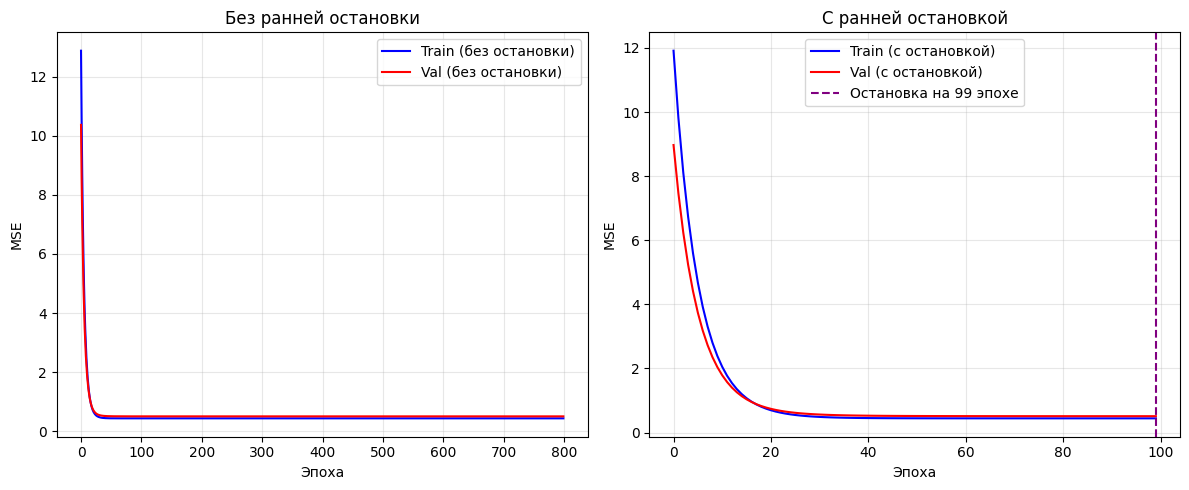

MSE на тестовой выборке без ранней остановки: 0.4577
MSE на тестовой выборке с ранней остановкой: 0.4579


In [ ]:
# Построение графиков
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_no, label='Train (без остановки)', color='blue')
plt.plot(val_no, label='Val (без остановки)', color='red')
plt.title('Без ранней остановки')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_stop, label='Train (с остановкой)', color = 'blue')
plt.plot(val_stop, label='Val (с остановкой)', color = 'red')
plt.axvline(x=stop_epoch, color='purple', linestyle='--', label=f'Остановка на {stop_epoch} эпохе')
plt.title('С ранней остановкой')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE на тестовой выборке без ранней остановки: {test_no:.4f}")
print(f"MSE на тестовой выборке с ранней остановкой: {test_stop:.4f}")

Для данной задачи сходимость наступает примерно к сотой эпохе и после этого значимого снижения MSE не происходит. Механизм ранней остановки завершает обучение, не позволяя модели уйти в переобучение. На сгенерированных для демонстрации данных модель не склонна переобучаться, поэтому мы не наблюдаем признаков переобучения на графике даже без применения механзима ранней остановки.

Обе реализации в итоге приходят примерно к одинаковому значению MSE на тестовой выборке, однако при применении механизма ранней остановки вычислительные ресурсы значительно экономятся, что может быть критично при использовании больших выборок.

Таким образом, механизм ранней остановки может использоваться не только для борьбы с переобучением, но и для оптимизации работы с вычислительными ресурсами.

---

## Задача 5. Сравнение L1- и L2-регуляризации

### Постановка задачи

Обучить две линейные модели на одном и том же датасете:
- одну с L1-регуляризацией (Lasso);
- другую с L2-регуляризацией (Ridge) при одинаковом $\lambda$ (например, 0.1).

Для обеих моделей сравнить:
- качество (MSE на валидации/тесте),
- разреженность весов (долю компонент, для которых $|w_j| < 0.01$),
- норму $\|w\|_2$.

### Теоретический минимум
- L1: $\Omega_{L1}(w) = \frac{\lambda}{2}\sum_j |w_j|$ → обычно даёт sparse-веса.
- L2: $\Omega_{L2}(w) = \frac{\lambda}{2}\sum_j w_j^2$ → сжимает веса, но редко делает их строго нулевыми.
- Геометрически: L1-шар — ромб, L2-шар — круг; точка минимума чаще попадает на вершину ромба, «обнуляя» координату.

Обучим две модели с L1 и L2 регуляризацией при разных значениях $\lambda$ и посмотрим, как различные значения параметра влияют на веса.

In [ ]:
def train_linear_with_l1(
    train_X: torch.Tensor,
    train_y: torch.Tensor,
    val_X: torch.Tensor,
    val_y: torch.Tensor,
    test_X: torch.Tensor,
    test_y: torch.Tensor,
    lam: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    """
    Обучает линейную регрессию с применением L1-регуляризации
    в течение заданного количества эпох

    Параметры:
        train_X: torch.Tensor
            Тензор с признаками для обучения
        train_y: torch.Tensor
            Тензор с целевыми значениями для обучения
        val_X: torch.Tensor
            Тензор с признаками для валидации
        val_y: torch.Tensor
            Тензор с целевыми значениями для валидации
        test_X: torch.Tensor
            Тензор с признаками для тестирования
        test_y: torch.Tensor
            Тензор с целевыми значениями для тестирования
        lam: float
            Коэффициент lambda
        lr: float
            Скорость обучения learning_rate
        epochs: int
            Количество эпох, в течение которых обучается модель

    Возвращает:
        weights_calculated: torch.Tensor
            Веса модели
        train_losses: list
            История потерь на обучающей выборке
        val_losses: list
            История потерь на валидационной выборке
        test_loss: float
            Ошибка на тестовой выборке
    """
    train_losses = []
    val_losses = []

    lin_reg = LinearRegressor(train_X.shape[1]).to(device)
    optimizer = optim.SGD(lin_reg.parameters(), lr=lr)

    for epoch in range(epochs):
        lin_reg.train()
        optimizer.zero_grad()
        y_pred = lin_reg(train_X)

        mse_loss = mse(y_pred, train_y)
        l1_reg = compute_l1_regularization(lin_reg.fc.weight, lam)
        loss_func = mse_loss + l1_reg

        loss_func.backward()
        optimizer.step()

        train_losses.append(mse_loss.item())

        # Валидационная выборка
        lin_reg.eval()
        with torch.no_grad():
            val_pred = lin_reg(val_X)
            val_loss = mse(val_pred, val_y)
            val_losses.append(val_loss.item())

    # Тестовая выборка
    lin_reg.eval()
    with torch.no_grad():
        test_pred = lin_reg(test_X)
        test_loss = mse(test_pred, test_y).item()
        weights_calculated = lin_reg.fc.weight.detach().view(-1, 1)

    return weights_calculated, train_losses, val_losses, test_loss

In [ ]:
# Сравнение: L1 и L2
results = {}
compare_lams = [0, 0.01, 0.1, 1.0]

# Общие данные для всех вызовов
data = (train_X_t, train_y_t, val_X_t, val_y_t, test_X_t, test_y_t)

for lam in compare_lams:
    w_l1, _, _, test_l1 = train_linear_with_l1(
        *data,
        lam=lam,
        lr=0.05,
        epochs=900
    )

    w_l2, _, _, test_l2 = train_linear_with_l2(
        *data,
        lam=lam,
        lr=0.05,
        epochs=900
    )

    l1_norm = torch.norm(w_l1)
    l2_norm = torch.norm(w_l2)
    sparsity_l1 = (torch.abs(w_l1) < 0.01).float().mean()
    sparsity_l2 = (torch.abs(w_l2) < 0.01).float().mean()

    results[lam] = {
        'weights_L1': w_l1,
        'weights_L2': w_l2,
        'test_loss_L1': test_l1,
        'test_loss_L2': test_l2,
        'l1_norm': l1_norm,
        'l2_norm': l2_norm,
        'sparsity_l1': sparsity_l1,
        'sparsity_l2': sparsity_l2
    }

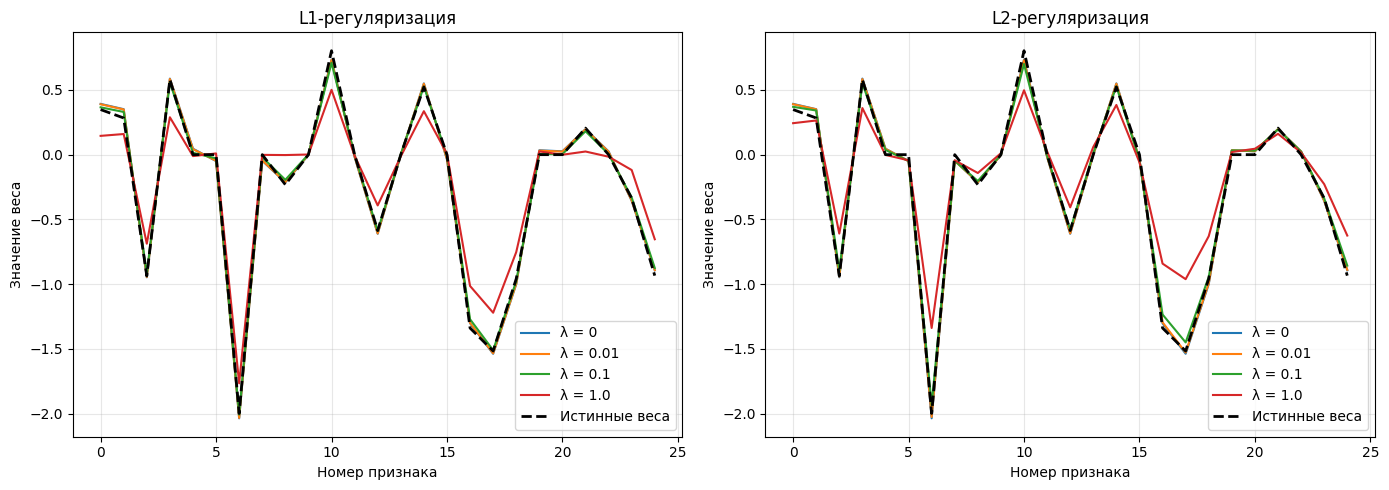

In [ ]:
# Строим графики изменения весов при разных lambda
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for lam in compare_lams:
    plt.plot(results[lam]['weights_L1'].cpu().numpy(), label=f'λ = {lam}')
plt.plot(w_true_t.cpu().numpy(), 'k--', label='Истинные веса', linewidth=2)
plt.xlabel('Номер признака')
plt.ylabel('Значение веса')
plt.title('L1-регуляризация')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for lam in compare_lams:
    plt.plot(results[lam]['weights_L2'].cpu().numpy(), label=f'λ = {lam}')
plt.plot(w_true_t.cpu().numpy(), 'k--', label='Истинные веса', linewidth=2)
plt.xlabel('Номер признака')
plt.ylabel('Значение веса')
plt.title('L2-регуляризация')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

При $\lambda$ < 1 визуально на графике сложно обнаружить явные различия, однако при $\lambda$ различия становятся явными:

- L1-регуляризация не сглаживает исходные веса модели, однако приводит к нулевым значениям по малым весам. Из-за этого веса становятся разреженными. Это демонстрирует, как L1-регуляризация стремится обнулить веса по признакам с маленькими исходными весами, считая их "незначительными";
- L2-регуляризация не зануляет исходные веса модели, но сглаживает их из-за чего кривая при $\lambda$ = 1 находится заметно дальше от кривой исходных весов. Таким образом, L2-регуляризация стремится "сгладить" веса модели, сделав их равномерными.

Теперь возьмем фиксированное значение $\lambda$ = 1 (для наглядности посмотрим на метрики при сильной регуляризации) и оценим модели по следующим параметрам:

- качество (MSE на валидации/тесте),
- разреженность весов (долю компонент, для которых $|w_j| < 0.01$),
- норму $\|w\|_2$

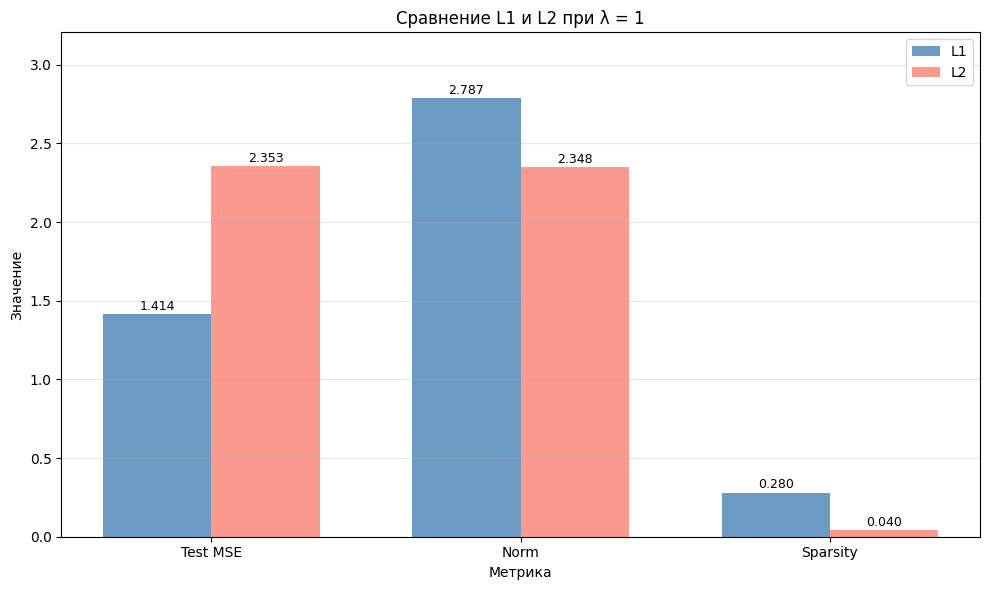

In [ ]:
# Строим диаграммы метрик при lambda = 1
lam_fixed = 1

metrics = ['Test MSE', 'Norm', 'Sparsity']
l1_values = [
    results[lam_fixed]['test_loss_L1'],
    results[lam_fixed]['l1_norm'].item(),
    results[lam_fixed]['sparsity_l1'].item()
]
l2_values = [
    results[lam_fixed]['test_loss_L2'],
    results[lam_fixed]['l2_norm'].item(),
    results[lam_fixed]['sparsity_l2'].item()
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

# Столбцы для L1
bars1 = plt.bar(x - width / 2, l1_values, width, label='L1', alpha=0.8, color='steelblue')

# Столбцы для L2
bars2 = plt.bar(x + width / 2, l2_values, width, label='L2', alpha=0.8, color='salmon')

# Добавляем подписи значений на столбцы L1
for bar, value in zip(bars1, l1_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

# Добавляем подписи значений на столбцы L2
for bar, value in zip(bars2, l2_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Метрика')
plt.ylabel('Значение')
plt.title(f'Сравнение L1 и L2 при λ = {lam_fixed}')
plt.xticks(x, metrics)
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.ylim(0, max(l1_values + l2_values) * 1.15)

plt.tight_layout()
plt.show()

Разница в значениях метрик при разных типах регуляризации наглядно показывает их различие:
- L1 зануляет примерно четверть весов (разреженность выше), что характерно для данного типа регуляризации.
- Норма L1 выше чем норма L2 (абсолютная сумма весов оказывается выше чем корень из суммы квадратов). Это подтверждает то, что L1-регуляризация занулила маленькие веса, просуммировав только большие. L2-регуляриация оставила даже небольшие веса, возведя их в квадрат из-за чего корень оказался меньше, чем линейная сумма весов.
- MSE на тестовой выборке при L1 регуляризации оказалась ниже чем при L2. Для данной задачи применение L1 регуляризации оказалось более эффективным, поскольку позволило занулить веса по некоторым признакам, приведя к меньшей зашумленности.

In [ ]:
# Обучение с L1
_, train_l1, val_l1, test_l1 = train_linear_with_l1(
    train_X_t, train_y_t,
    val_X_t, val_y_t,
    test_X_t, test_y_t,
    lam=1,
    epochs=900
)

# Обучение с L2
_, train_l2, val_l2, test_l2 = train_linear_with_l2(
    train_X_t, train_y_t,
    val_X_t, val_y_t,
    test_X_t, test_y_t,
    lam=1,
    epochs=900
)

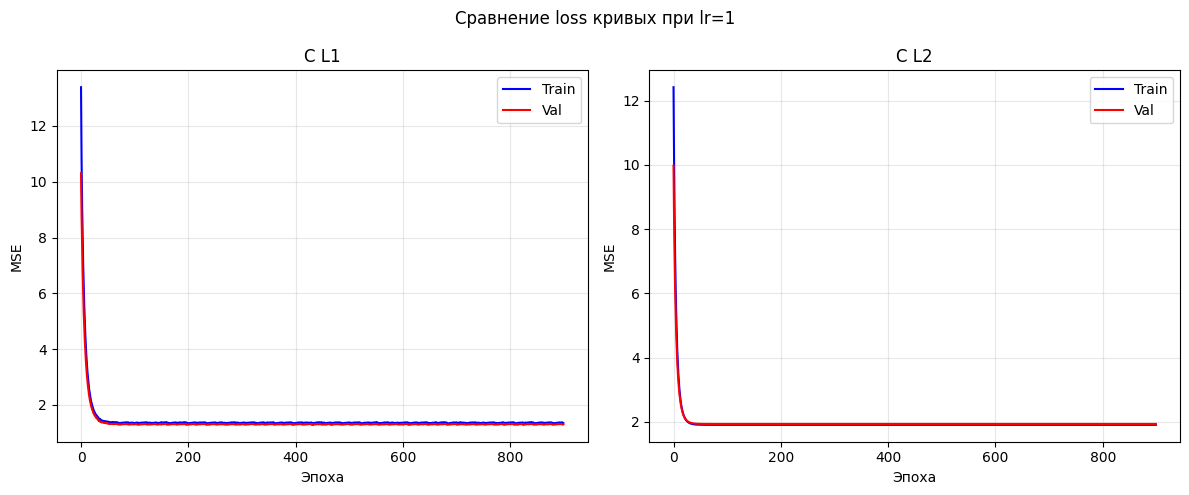

MSE на тестовой выборке с L1: 1.4249
MSE на тестовой выборке с L2: 2.3535


In [ ]:
# Построение графиков
plt.figure(figsize=(12, 5))

plt.suptitle("Сравнение loss кривых при lr=1")

plt.subplot(1, 2, 1)
plt.plot(train_l1, label='Train', color='blue')
plt.plot(val_l1, label='Val', color='red')
plt.title('C L1')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_l2, label='Train', color='blue')
plt.plot(val_l2, label='Val', color='red')
plt.title('С L2')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE на тестовой выборке с L1: {test_l1:.4f}")
print(f"MSE на тестовой выборке с L2: {test_l2:.4f}")

При сильной регуляризации ($\lambda$ = 1) кривая обучения L1 демонстрирует мелкие колебания, в то время как L2 остается гладкой. Это связано с с тем, что при L1 регуляризации градиент (sign(w)) терпит разрыв в нуле, из-за чего веса, близкие к нулю, начинают колебаться. L2-регуляризатор, напротив, имеет непрерывную производную (2w), что обеспечивает плавную сходимость. Несмотря на колебания, сходимость по L1 также была достигнута.

---

## Задача 6. Эксперимент с λ

### Постановка задачи

Исследовать влияние коэффициента регуляризации $\lambda$ на качество L2-регуляризованной модели и величину весов. Необходимо:
- перебрать набор значений $\lambda$;
- обучить модель для каждого значения;
- собрать и визуализировать зависимости `val_loss` и $\|w\|_2$ от $\lambda$.

### Теоретический минимум
- При маленьком $\lambda$ модель почти без регуляризации → низкий bias, высокий variance (overfitting).
- При большом $\lambda$ веса сильно сжаты → высокий bias, низкий variance (underfitting).
- Оптимальное $\lambda$ обычно выбирают по минимуму val_loss.

In [ ]:
lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
val_losses = []
test_losses = []
norms = []

# Общие данные для всех вызовов
data = (train_X_t, train_y_t, val_X_t, val_y_t, test_X_t, test_y_t)

for lam in lambdas:
    w, _, val_loss_history, test_loss = train_linear_with_l2(
        *data,
        lam=lam,
        lr=0.05,
        epochs=900
    )
    w_norm = torch.norm(w)
    test_losses.append(test_loss)
    val_losses.append(val_loss_history[-1])
    norms.append(w_norm)

for lam, v, n in zip(lambdas, val_losses, norms):
    print(f"λ={lam:<6} | val MSE={v:.4f} | ||w||2={n:.3f}")

λ=0.0    | val MSE=0.5110 | ||w||2=3.601
λ=0.0001 | val MSE=0.5110 | ||w||2=3.601
λ=0.001  | val MSE=0.5109 | ||w||2=3.599
λ=0.01   | val MSE=0.5109 | ||w||2=3.581
λ=0.1    | val MSE=0.5382 | ||w||2=3.416
λ=1.0    | val MSE=1.9356 | ||w||2=2.348
λ=10.0   | val MSE=8.8293 | ||w||2=0.577


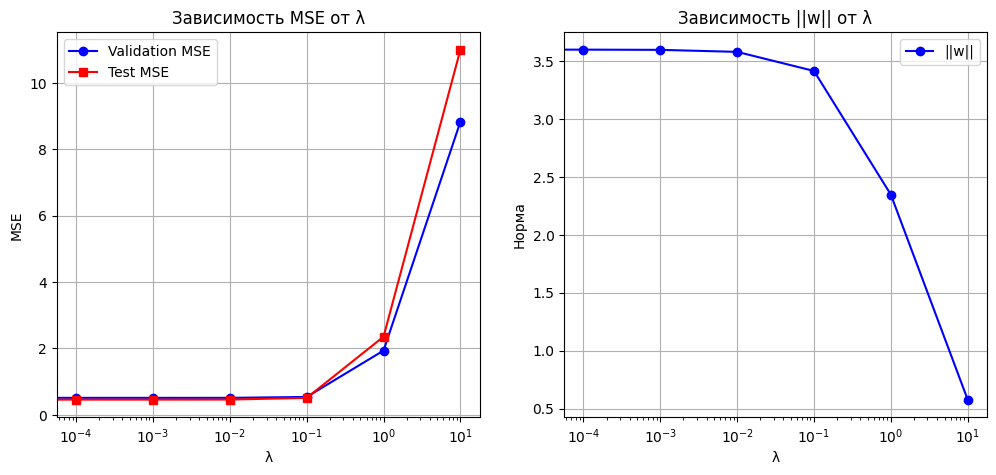

In [ ]:
# Графики зависимостей от log10(lambda)
plt.figure(figsize=(12, 5))

# Строим график MSE vs λ
plt.subplot(1, 2, 1)
plt.xscale('log')

plt.plot(lambdas, val_losses, 'o-', label='Validation MSE', color='blue')
plt.plot(lambdas, test_losses, 's-', label='Test MSE', color='red')

plt.xlabel('λ')
plt.ylabel('MSE')
plt.legend()
plt.title('Зависимость MSE от λ')
plt.grid(True)

# Строим график ||w|| vs λ
plt.subplot(1, 2, 2)
plt.xscale('log')

plt.plot(lambdas, norms, 'o-', label='||w||', color='blue')
plt.xlabel('λ')
plt.ylabel('Норма')
plt.legend()
plt.title('Зависимость ||w|| от λ')
plt.grid(True)
plt.show()


Минимальное значение loss на тестовой выборке достигается при малых значениях $\lambda$ (<=0.1). При больших значениях модель начинает недообучаться.

Признаки переобучения на данном наборе данных при малых $\lambda$ не наблюдаются, однако при другом наборе данных слабое влияние регуляризации может привести к переобучению.

С увеличением $\lambda$ норма начинает сокращаться. Усиление регуляризации приводит к более сильному сглаживнию весов, из-за чего их числовые значения уменьшаются и как следствие умньшается корень из суммы квадратов.

---

## Задача 7. Визуализация кривых обучения

### Постановка задачи

Необходимо обучить несколько вариантов одной и той же модели (например, без регуляризации, с L2 и с Early Stopping) и визуализировать кривые обучения: train loss и val loss по эпохам. На основе графиков нужно проанализировать, где начинается переобучение и как разные методы регуляризации его сдерживают.

### Теоретический минимум
- Кривая обучения: train/val loss как функция номера эпохи.
- Признак переобучения: train loss продолжает падать, а val loss начинает расти.
- Регуляризация (L2, Early Stopping) уменьшает разрыв между train и val, сглаживая кривые.

Для данной задачи сгенерируем новый набор данных, так как исходный является слишком простым и до их пор модель не демонстрировала явных признаков переобучения.

В новой выборке увеличим количество признаков, уменьшим количество наблюдений, а также добавим разреженность признаков и сильный шум.

In [ ]:
# Генерируем новые данные с большим количеством признаков (для переобучения)
X_new, y_new, _ = make_synthetic_linear_regression(
    n=200,
    d=100,
    noise_std=2,
    sparsity=0.8
)

# Разделяем на train/val/test
(train_X_new, train_y_new), (val_X_new, val_y_new), (test_X_new, test_y_new) = train_val_test_split(
    X_new, y_new, 0.6, 0.2
)

# Преобразуем в тензоры
train_X_t_new = to_tensor(train_X_new)
train_y_t_new = to_tensor(train_y_new).view(-1, 1)

val_X_t_new = to_tensor(val_X_new)
val_y_t_new = to_tensor(val_y_new).view(-1, 1)

test_X_t_new = to_tensor(test_X_new)
test_y_t_new = to_tensor(test_y_new).view(-1, 1)

Обучим три модели:

- Без регуляризации;
- С L1-регуляризацией (при $\lambda$ = 1);
- С L2-регуляризацией (при $\lambda$ = 1);
- С ранней остановкой.

Обучаться будем в течение 800 эпох.

In [ ]:
# Без регуляризации
_, train_noreg, val_noreg, test_noreg = train_linear_with_weight_decay(
    train_X_t_new, train_y_t_new,
    val_X_t_new, val_y_t_new,
    test_X_t_new, test_y_t_new,
    epochs=800,
    weight_decay=0.0
)

# Обучение с L1
_, train_l1, val_l1, test_l1 = train_linear_with_l1(
    train_X_t_new, train_y_t_new,
    val_X_t_new, val_y_t_new,
    test_X_t_new, test_y_t_new,
    lam=0.1,
    epochs=800
)

# Обучение с L2
_, train_l2, val_l2, test_l2 = train_linear_with_l2(
    train_X_t_new, train_y_t_new,
    val_X_t_new, val_y_t_new,
    test_X_t_new, test_y_t_new,
    lam=0.1,
    epochs=800
)

# Обучение с ранней остановкой
stop_epoch, _, train_stop, val_stop, test_stop = train_linear_with_early_stop(
    train_X_t_new, train_y_t_new,
    val_X_t_new, val_y_t_new,
    test_X_t_new, test_y_t_new,
    epochs=800
)

Ранняя остановка на 41 эпохе


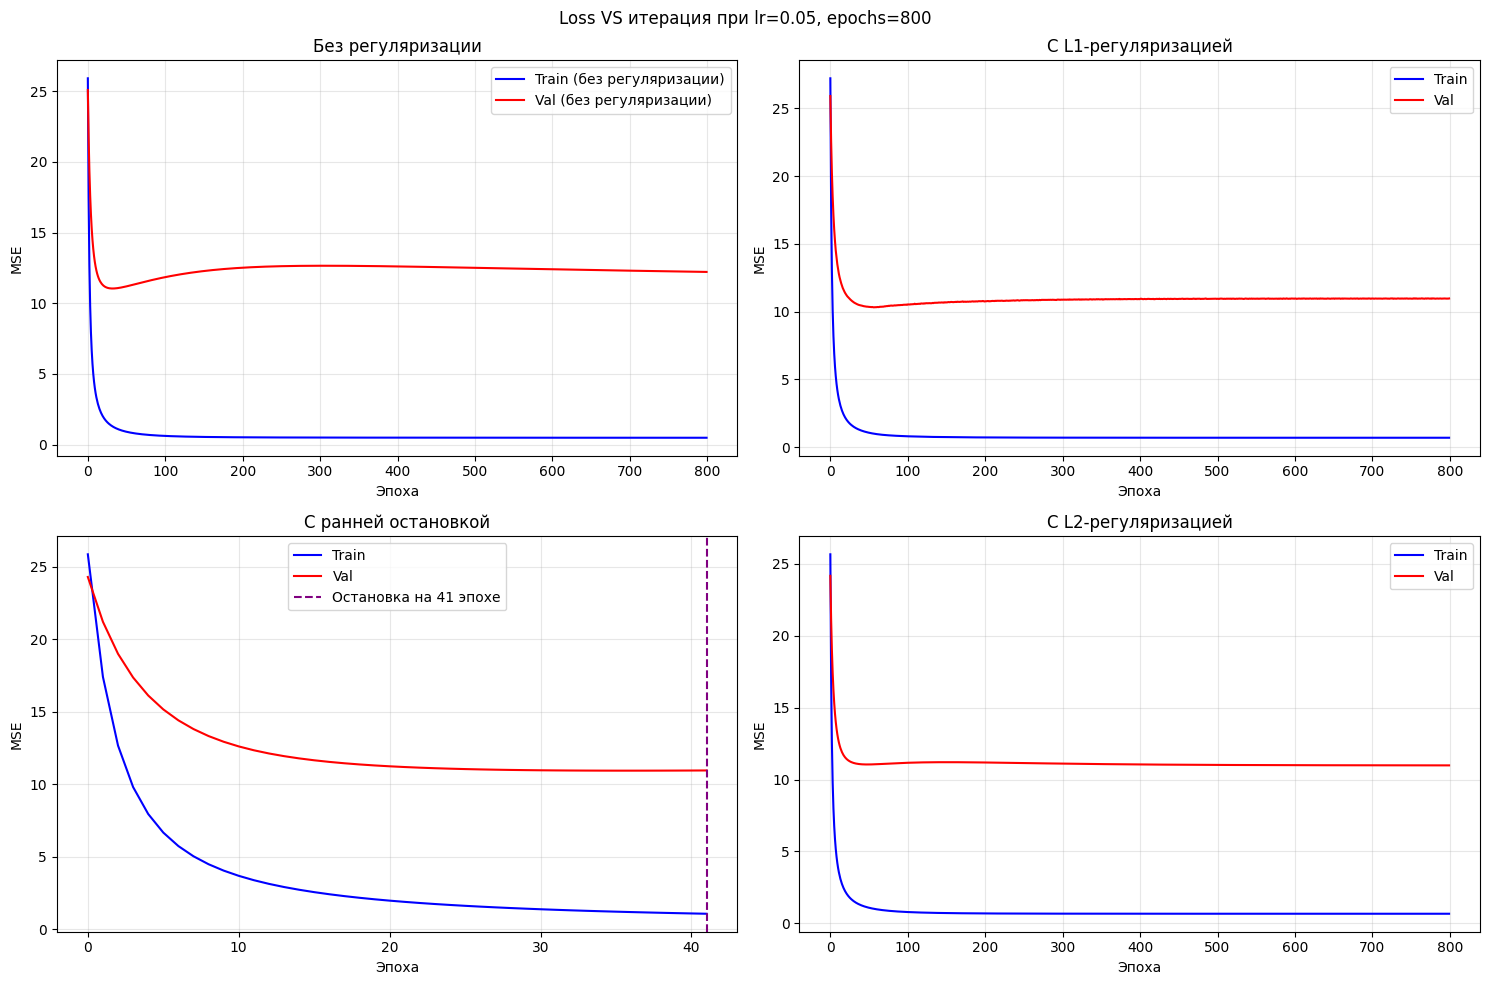

MSE на тестовой выборке без регуляризации: 11.9567
MSE на тестовой выборке с L1-регуляризацией: 7.1643
MSE на тестовой выборке с L2-регуляризацией: 8.0401
MSE на тестовой выборке с ранней остановкой: 6.7703


In [ ]:
# Построение графиков
plt.figure(figsize=(15, 10))

plt.suptitle("Loss VS итерация при lr=0.05, epochs=800")

plt.subplot(2, 2, 1)
plt.plot(train_noreg, label='Train (без регуляризации)', color='blue')
plt.plot(val_noreg, label='Val (без регуляризации)', color='red')
plt.title('Без регуляризации')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(train_l1, label='Train', color='blue')
plt.plot(val_l1, label='Val', color='red')
plt.title('С L1-регуляризацией')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(train_stop, label='Train', color='blue')
plt.plot(val_stop, label='Val', color='red')
plt.axvline(x=stop_epoch, color='purple', linestyle='--', label=f'Остановка на {stop_epoch} эпохе')
plt.title('С ранней остановкой')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(train_l2, label='Train', color='blue')
plt.plot(val_l2, label='Val', color='red')
plt.title('С L2-регуляризацией')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE на тестовой выборке без регуляризации: {test_noreg:.4f}")
print(f"MSE на тестовой выборке с L1-регуляризацией: {test_l1:.4f}")
print(f"MSE на тестовой выборке с L2-регуляризацией: {test_l2:.4f}")
print(f"MSE на тестовой выборке с ранней остановкой: {test_stop:.4f}")

Механизм ранней остановки оказался наиболее эффективным, прекратив обучение после того, как значимые улучшения перестали наступать.
L1 регуляризация оказалась более эффективна чем L2 регуляризация на данном наборе данных, поскольку при генерации мы задали высокий коэффициент разреженности весов, что позволило L1-регуляризации сработать более эффективно.

Обучение без регуляризации ожидаемо продемонстрировало самый плохой результат и самый высокий MSE на тестовой выборке.

Таким образом, выбор способа регуляризации должен быть продиктован свойствами наших данных (разреженность весов, наличие шума, количество наблюдений и признаков).

---

## Задача 8. Monte Carlo Dropout

### Постановка задачи

Реализовать функцию `mc_dropout_predict(model, X, n_samples)`, которая оценивает предсказания и неопределенность регрессионной нейросети с Dropout. Для этого нужно:
- выполнить `n_samples` прямых проходов модели в режиме `train()` (чтобы Dropout был активен);
- накапливать предсказания на одной и той же выборке `X`;
- вернуть среднее и стандартное отклонение предсказаний.

Применить метод к тестовым данным и визуализировать средние предсказания и доверительный интервал.

### Теоретический минимум
- Dropout: при обучении случайно обнуляются выходы нейронов с вероятностью $p$, при инференсе используется масштабирование.
- Monte Carlo Dropout (Галь, Гхахрамани): оставляем Dropout включенным на инференсе и делаем многократные прогоны; дисперсия по семплам ≈ неопределенность модели.
- Для регрессии удобно визуализировать mean ± 2·std как приближенный доверительный интервал.

Для наглядной визуализации сделаем 1D-регрессию (синус + шум). Для этого создадим функцию `make_1d_regression`.

In [ ]:
def make_1d_regression(n=250, noise=0.15):
    """
    Создает 1D-регрессию в диапазоне [-3π; 3π]

    Параметры:
        n: int
            Количество наблюдений
        noise: float
            Стандартное отклонение для шума

    Возвращает:
        X: np.array
            Массив с данными
        y: np.array
            Массив с предсказаниями
    """
    X = np.linspace(-3 * np.pi, 3 * np.pi, n)
    y_sin = np.sin(X)

    y = y_sin + np.random.normal(0, noise, n)

    return X.reshape(-1, 1), y

Создадим данные из 500 наблюдений.

In [ ]:
# Генерируем данные
X1, y1 = make_1d_regression(n=500)

# Разделяем на train/test
train_X_1d, test_X_1d, train_y_1d, test_y_1d = train_test_split(
    X1, y1, train_size=0.8, random_state=SEED
)

# Преобразуем в тензоры
train_X_t_1d = to_tensor(train_X_1d)
train_y_t_1d = to_tensor(train_y_1d).view(-1, 1)

test_X_t_1d = to_tensor(test_X_1d)
test_y_t_1d = to_tensor(test_y_1d).view(-1, 1)

Создадим модель с архитектурой:

$$Input(1) \rightarrow Linear(1, 32) \rightarrow ReLU \rightarrow DropOut(p) \rightarrow Linear(32, 16) \rightarrow ReLU \rightarrow DropOut(p) \rightarrow Linear(16, 1) \rightarrow Output(1)$$

где $p$ — вероятность обнуления нейрона в слое Dropout.

In [ ]:
class MLPDropout(nn.Module):
    """
    Класс многослойной сети с Dropout

    Атрибуты:
        fc1: torch.nn.Linear
            Первый полносвязный слой (вход: 1 признак, выход: 64 нейрона)
        fc2: torch.nn.Linear
            Второй полносвязный слой (вход: 64 нейрона, выход: 32 нейрона)
        fc3: torch.nn.Linear
            Третий полносвязный слой (вход: 32 нейрона, выход: 1 нейрон)
        dropout: torch.nn.Dropout
            Слой Dropout для регуляризации

    Параметры:
        p: float
            Вероятность обнуления нейрона в слое Dropout (по умолчанию 0.2)

    Методы:
        forward(x)
            Прямой проход через модель
    """

    def __init__(self, p=0.2):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(p=p)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

Создадим функцию для обучения модели.

In [ ]:
def train_mlp(model, lr=0.01, epochs=2000):
    """
    Обучает многослойную сеть с Dropout
    в течение заданного количества эпох

    Параметры:
        model: torch.nn.Module
            Модель для обучения
        lr: float
            Скорость обучения learning_rate
        epochs: int
            Количество эпох, в течение которых обучается модель

    Возвращает:
        model: torch.nn.Module
            Обученная модель
        train_losses: list
            История потерь на обучающей выборке
    """
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(train_X_t_1d)

        loss_func = mse(y_pred_train, train_y_t_1d)

        loss_func.backward()
        optimizer.step()

        train_losses.append(loss_func.item())

    return model, train_losses

In [ ]:
def mc_dropout_predict(model: nn.Module, X: torch.Tensor, n_samples: int = 100):
    """
    Оценивает предсказания и неопределенность модели с Dropout.

    Параметры:
        model: nn.Module
            Модель с слоями Dropout
        X: torch.Tensor
            Входные данные
        n_samples: int
            Количество прогонов для оценки

    Возвращает:
        mean: torch.Tensor
            Средние предсказания
        std: torch.Tensor
            Стандартное отклонение предсказаний
    """
    model.train()  # Включаем Dropout
    predictions = []

    with torch.no_grad():
        for _ in range(n_samples):
            pred = model(X)
            predictions.append(pred)

    predictions = torch.stack(predictions, dim=0)
    mean = predictions.mean(dim=0)
    std = predictions.std(dim=0)

    return mean, std

In [ ]:
mlp = MLPDropout(p=0.05).to(device)
mlp, losses = train_mlp(mlp)

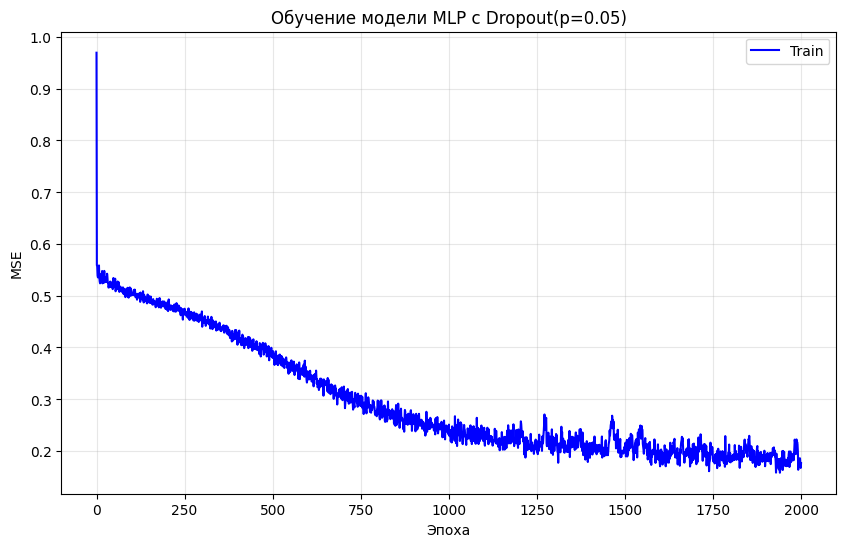

In [ ]:
# Визуализируем train loss
plt.figure(figsize=(10, 6))

plt.plot(losses, label='Train', color='blue')
plt.title('Обучение модели MLP с Dropout(p=0.05)')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

Несмотря на зашумленность, мы наблюдаемм убывание MSE на обучающей выборке.
Зашумленность связана с особенностями обучения: механизм DropOut выключает случайно выбранные нейроны, добавляя дополнительную стохастичность в процесс.

Оценим неопределенность модели, построив график. Отложим исходные точки тестовой выборки для демонстрации распределения данных, и построим линию средних предсказаний модели (`mean`) на test, а также доверительные интервалы (`std`)

In [ ]:
# Оцениваем качество на тестовой выборке
mean_pred, std_pred = mc_dropout_predict(model=mlp, X=test_X_t_1d)

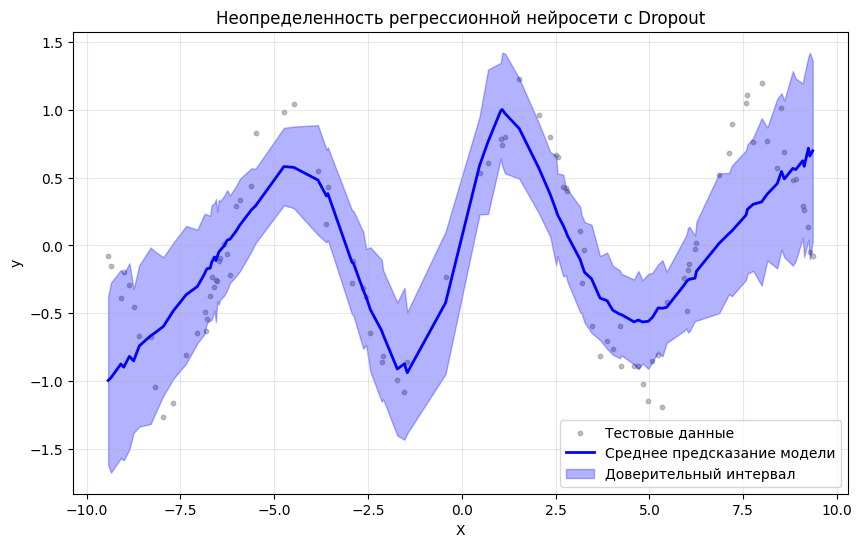

In [ ]:
plt.figure(figsize=(10, 6))

# Исходные точки
plt.scatter(test_X_t_1d, test_y_t_1d, s=10, alpha=0.5, color='gray', label='Тестовые данные')

# Сортируем тестовые данные
sort_idx = test_X_t_1d.argsort(axis=0).flatten()
X_test_sorted = test_X_t_1d[sort_idx]
mean_sorted = mean_pred[sort_idx]
std_sorted = std_pred[sort_idx]

# Среднее предсказание
plt.plot(X_test_sorted.cpu().numpy(), mean_sorted.cpu().numpy(), 'b-',
         label='Среднее предсказание модели', linewidth=2)

# Доверительный интервал (mean ± 2·std)
plt.fill_between(X_test_sorted.cpu().numpy().flatten(),
                 (mean_sorted - 2 * std_sorted).cpu().numpy().flatten(),
                 (mean_sorted + 2 * std_sorted).cpu().numpy().flatten(),
                 alpha=0.3, color='blue', label='Доверительный интервал')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Неопределенность регрессионной нейросети с Dropout')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

На графике видно, что линия предсказаний повторяет форму синусоиды исходных данных. В середине графика область доверительных интервалов меньше, что указывает на большую уверенность модели в предсказаниях. По краям графика области доверительных интервалов шире, так как количество наблюдений по краям меньше, что снижает уверенность модели в предсказаниях, вынуждая ее расширять доверительные интервалы.

---

## Задача 9. Комплексное сравнение

### Постановка задачи

Сравнить на одном и том же датасете несколько методов регуляризации:
1. Без регуляризации.
2. L2 (λ = 0.1).
3. L1 (λ = 0.1).
4. Elastic Net (смешение L1 и L2).
5. Early Stopping.

Для каждой модели вычислить:
- Test MSE;
- норму весов $\|w\|_2$;
- разреженность (долю весов, по модулю меньше 0.01).

Соберать результаты в таблицу и проанализировать, какой метод дает лучший компромисс между качеством и сложностью модели.

### Теоретический минимум
- Elastic Net: $L = E(w) + \alpha \lambda \|w\|_1 + (1-\alpha) \lambda \|w\|_2^2/2$.
- Разные методы по-разному влияют на bias/variance и структуру весов (сильная L1 → сильно разреженные модели, L2/ES → более гладкие веса, Dropout → «шумная», но устойчиво обобщающая модель).
- Комплексное сравнение по нескольким метрикам позволяет понять, что важнее: точность, интерпретируемость или устойчивость.

Сравним на одном и том же датасете несколько методов регуляризации:
- Без регуляризации.
- L2 (λ = 0.1).
- L1 (λ = 0.1).
- Elastic Net (смешение L1 и L2).
- Early Stopping.

Для этого сгенерируем новый набор данных.

In [ ]:
# Генерируем данные
X_final, y_final, w_true_final = make_synthetic_linear_regression(
    n=200,
    d=50,
    noise_std=1.0,
    sparsity=0.6
)

In [ ]:
# Разделяем на train/val/test
(train_X_final, train_y_final), (val_X_final, val_y_final), (test_X_final, test_y_final) = train_val_test_split(
    X_final, y_final, 0.6, 0.2
)

# Преобразуем в тензоры
train_X_final_t = to_tensor(train_X_final)
train_y_final_t = to_tensor(train_y_final).view(-1, 1)

val_X_final_t = to_tensor(val_X_final)
val_y_final_t = to_tensor(val_y_final).view(-1, 1)

test_X_final_t = to_tensor(test_X_final)
test_y_final_t = to_tensor(test_y_final).view(-1, 1)

w_true_final_t = to_tensor(w_true_final).view(-1, 1)

In [ ]:
# Исходные норма и разреженность
true_norm = torch.norm(w_true_final_t)
true_sparsity = (torch.abs(w_true_final_t) < 0.01).float().mean().item()

Реализуем функцию для применения Elastic-Net:

$$L = E(w) + \alpha \lambda \|w\|_1 + (1-\alpha) \lambda \|w\|_2^2/2$$

In [ ]:
def train_linear_elastic_net(
    train_X: torch.Tensor,
    train_y: torch.Tensor,
    val_X: torch.Tensor,
    val_y: torch.Tensor,
    test_X: torch.Tensor,
    test_y: torch.Tensor,
    lam: float,
    alpha: float = 0.5,   # доля L1
    lr: float = 0.05,
    epochs: int = 900,
):
    """
    Обучает линейную регрессию с применением Elastic-Net
    в течение заданного количества эпох

    Параметры:
        train_X: torch.Tensor
            Тензор с признаками для обучения
        train_y: torch.Tensor
            Тензор с целевыми значениями для обучения
        val_X: torch.Tensor
            Тензор с признаками для валидации
        val_y: torch.Tensor
            Тензор с целевыми значениями для валидации
        test_X: torch.Tensor
            Тензор с признаками для тестирования
        test_y: torch.Tensor
            Тензор с целевыми значениями для тестирования
        lam: float
            Коэффициент lambda
        alpha: float
            Коэффициент alpha (регулирует долю L1-рег.)
        lr: float
            Скорость обучения learning_rate
        epochs: int
            Количество эпох, в течение которых обучается модель

    Возвращает:
        weights_calculated: torch.Tensor
            Веса модели
        train_losses: list
            История потерь на обучающей выборке
        val_losses: list
            История потерь на валидационной выборке
        test_loss: float
            Ошибка на тестовой выборке
    """
    train_losses = []
    val_losses = []

    lin_reg = LinearRegressor(train_X.shape[1]).to(device)
    optimizer = optim.SGD(lin_reg.parameters(), lr=lr)

    for epoch in range(epochs):
        lin_reg.train()
        optimizer.zero_grad()
        y_pred = lin_reg(train_X)

        mse_loss = mse(y_pred, train_y)
        l2_reg = compute_l2_regularization(lin_reg.fc.weight, 1.0)
        l1_reg = compute_l1_regularization(lin_reg.fc.weight, 1.0)
        loss_func = mse_loss + lam * (alpha * l1_reg + (1 - alpha) * l2_reg)

        loss_func.backward()
        optimizer.step()

        train_losses.append(mse_loss.item())

        # Валидационная выборка
        lin_reg.eval()
        with torch.no_grad():
            val_pred = lin_reg(val_X)
            val_loss = mse(val_pred, val_y)
            val_losses.append(val_loss.item())

    # Тестовая выборка
    lin_reg.eval()
    with torch.no_grad():
        test_pred = lin_reg(test_X)
        test_loss = mse(test_pred, test_y).item()
        weights_calculated = lin_reg.fc.weight.detach().view(-1, 1)

    return weights_calculated, train_losses, val_losses, test_loss

Наконец обучим пять моделей и сравним их между собой по метрикам:
- Test MSE;
- норму весов  ‖𝑤‖2 ;
- разреженность (долю весов, по модулю меньше 0.01).

In [ ]:
# Без регуляризации
w_no_reg, train_losses_no_reg, val_losses_no_reg, test_no_reg = train_linear_with_weight_decay(
    train_X_final_t, train_y_final_t,
    val_X_final_t, val_y_final_t,
    test_X_final_t, test_y_final_t,
    weight_decay=0.0,
    lr=0.05,
    epochs=800
)

no_reg_norm = torch.norm(w_no_reg)
no_reg_sparsity = (torch.abs(w_no_reg) < 0.01).float().mean().item()

In [ ]:
# L2 (λ=0.1)
lam = 0.1

weights_l2, train_losses_l2, val_losses_l2, test_loss_l2 = train_linear_with_l2(
    train_X_final_t, train_y_final_t,
    val_X_final_t, val_y_final_t,
    test_X_final_t, test_y_final_t,
    lam=lam,
    lr=0.05,
    epochs=800
)

l2_norm = torch.norm(weights_l2)
l2_sparsity = (torch.abs(weights_l2) < 0.01).float().mean().item()

In [ ]:
# L1 (λ=0.1)
weights_l1, train_losses_l1, val_losses_l1, test_loss_l1 = train_linear_with_l1(
    train_X_final_t, train_y_final_t,
    val_X_final_t, val_y_final_t,
    test_X_final_t, test_y_final_t,
    lam=lam,
    lr=0.05,
    epochs=800
)

l1_norm = torch.norm(weights_l1)
l1_sparsity = (torch.abs(weights_l1) < 0.01).float().mean().item()

In [ ]:
# Elastic Net (λ=0.1, alpha=0.5)
w_elastic, train_losses_elastic, val_losses_elastic, test_elastic = train_linear_elastic_net(
    train_X_final_t, train_y_final_t,
    val_X_final_t, val_y_final_t,
    test_X_final_t, test_y_final_t,
    lam=lam,
    alpha=0.5,
    lr=0.05,
    epochs=800
)

elastic_norm = torch.norm(w_elastic)
elastic_sparsity = (torch.abs(w_elastic) < 0.01).float().mean().item()

In [ ]:
# Early Stopping (без явного L2)
stop_epoch, w_stop, train_stop, val_stop, test_stop = train_linear_with_early_stop(
    train_X_final_t, train_y_final_t,
    val_X_final_t, val_y_final_t,
    test_X_final_t, test_y_final_t,
    lr=0.05,
    epochs=800
)

stop_norm = torch.norm(w_stop)
stop_sparsity = (torch.abs(w_stop) < 0.01).float().mean().item()

Ранняя остановка на 453 эпохе


In [ ]:
# Записываем метрики в датафрейм
summary_dict = {
    'name': ['True', 'No_reg', 'L2', 'L1', 'Elastic (alpha=0.5)', 'Early_Stop'],
    'weights': [w_true_final_t, w_no_reg, weights_l2, weights_l1, w_elastic, w_stop],
    'test_loss': [None, test_no_reg, test_loss_l2, test_loss_l1, test_elastic, test_stop],
    'norm': [true_norm, no_reg_norm, l2_norm, l1_norm, elastic_norm, stop_norm],
    'sparsity': [true_sparsity, no_reg_sparsity, l2_sparsity, l1_sparsity, elastic_sparsity, stop_sparsity]
}

summary_df = pd.DataFrame(summary_dict)

In [ ]:
# Форматируем вывод
df_sorted = summary_df.sort_values(by='test_loss').copy()

df_sorted['test_loss'] = df_sorted['test_loss'].round(4)
df_sorted['norm'] = df_sorted['norm'].round(4)
df_sorted['sparsity'] = df_sorted['sparsity'].round(4)

# Создаем стили для выделения
def highlight_min_loss(row):
    """Выделяет строку с минимальным test_loss"""
    is_min = row['test_loss'] == df_sorted['test_loss'].min()
    return ['background-color: lightgreen' if is_min else '' for _ in row]


def highlight_true(row):
    """Выделяет строку с истинными весами"""
    is_true = row['name'] == 'True'
    return ['background-color: lightblue' if is_true else '' for _ in row]


# Применяем стили
styled_df = (df_sorted.style
    .apply(highlight_min_loss, axis=1)
    .apply(highlight_true, axis=1)
    .format({
        'test_loss': '{:.4f}',
        'norm': '{:.4f}',
        'sparsity': '{:.4f}'
    })
    .set_caption('Сравнение методов регуляризации')
    .hide(axis='index')
)

display(styled_df)

name,weights,test_loss,norm,sparsity
L1,"tensor([[-5.1709e-01], [ 1.3666e+00], [-1.3926e+00], [-4.9344e-01], [-3.2099e-01], [ 1.4237e-03], [-1.7797e-04], [ 7.6173e-04], [-7.2591e-02], [ 6.4658e-03], [-2.4586e-01], [ 1.3239e-01], [ 1.4106e+00], [ 5.3907e-04], [ 1.0706e+00], [-1.4100e-01], [-6.4618e-02], [ 2.1709e+00], [ 7.7521e-01], [-3.3956e-02], [-3.0960e-02], [ 1.0266e-01], [ 4.0740e-02], [-6.3053e-02], [-1.8829e-02], [ 7.3766e-02], [-5.9570e-01], [ 9.2344e-03], [-1.2994e-02], [-2.8047e-03], [-5.3591e-02], [ 2.2810e-01], [-7.8814e-02], [-2.0667e-01], [ 4.6100e-02], [ 1.3821e-01], [-3.0474e-01], [-6.1618e-02], [-1.4467e+00], [ 2.6267e-02], [ 9.0871e-01], [ 2.3237e-02], [ 3.6689e-03], [-1.9751e-04], [-5.1262e-04], [-4.7942e-02], [-2.4216e-01], [-7.3993e-02], [ 1.0227e-01], [ 9.8163e-02]])",1.2798,4.0725,0.2000
Elastic (alpha=0.5),"tensor([[-5.3852e-01], [ 1.3133e+00], [-1.3441e+00], [-4.4724e-01], [-3.3048e-01], [ 6.1640e-03], [ 2.8485e-02], [ 1.3401e-04], [-9.6808e-02], [ 4.4273e-04], [-2.5404e-01], [ 1.6691e-01], [ 1.4015e+00], [ 1.5470e-02], [ 1.0452e+00], [-1.2411e-01], [-8.6491e-02], [ 2.1088e+00], [ 7.4348e-01], [-3.5735e-02], [-2.7150e-02], [ 1.1743e-01], [ 6.6094e-02], [-7.1819e-02], [-4.1113e-02], [ 8.0342e-02], [-5.7474e-01], [ 3.7962e-02], [-1.8500e-02], [-2.8714e-02], [-4.4489e-02], [ 2.4012e-01], [-1.0573e-01], [-2.1343e-01], [ 6.4682e-02], [ 1.6638e-01], [-3.3795e-01], [-7.6616e-02], [-1.4365e+00], [ 1.9863e-02], [ 8.9921e-01], [ 5.2405e-02], [ 1.0110e-02], [ 2.0959e-03], [-3.7910e-02], [-4.9404e-02], [-2.6230e-01], [-1.0021e-01], [ 1.0200e-01], [ 1.3356e-01]])",1.3396,3.9917,0.0800
L2,"tensor([[-0.5535], [ 1.2633], [-1.2941], [-0.3940], [-0.3500], [ 0.0334], [ 0.0725], [-0.0148], [-0.1206], [-0.0263], [-0.2621], [ 0.1908], [ 1.3896], [ 0.0712], [ 1.0267], [-0.1028], [-0.1105], [ 2.0381], [ 0.7121], [-0.0422], [-0.0231], [ 0.1309], [ 0.0801], [-0.0881], [-0.0603], [ 0.0925], [-0.5552], [ 0.0541], [-0.0168], [-0.0627], [-0.0347], [ 0.2625], [-0.1357], [-0.2156], [ 0.0801], [ 0.1824], [-0.3686], [-0.0978], [-1.4232], [ 0.0128], [ 0.8904], [ 0.0908], [ 0.0397], [ 0.0031], [-0.0770], [-0.0498], [-0.2819], [-0.1249], [ 0.1049], [ 0.1661]])",1.4560,3.9125,0.0200
No_reg,"tensor([[-5.4874e-01], [ 1.4240e+00], [-1.4293e+00], [-4.8111e-01], [-3.4892e-01], [ 3.0985e-02], [ 3.5155e-03], [-2.2890e-02], [-1.4418e-01], [ 3.5271e-02], [-2.6855e-01], [ 2.0116e-01], [ 1.4612e+00], [-2.4563e-02], [ 1.1178e+00], [-2.1073e-01], [-9.0134e-02], [ 2.2110e+00], [ 8.0552e-01], [-3.0256e-02], [-4.2565e-02], [ 1.4852e-01], [ 1.0020e-01], [-9.4382e-02], [-3.9533e-02], [ 1.1503e-01], [-5.9692e-01], [ 4.7638e-02], [-7.2181e-02], [-5.3411e-02], [-1.0373e-01], [ 2.6659e-01], [-1.2695e-01], [-2.1307e-01], [ 5.9030e-02], [ 2.1263e-01], [-3.3834e-01], [-7.3677e-02], [-1.5176e+00], [ 8.5234e-02], [ 9.6316e-01], [ 2.3887e-02], [ 4.2846e-02], [ 7.0036e-05], [ 6.5687e-04], [-1.0220e-01], [-3.4129e-01], [-9.3380e-02], [ 1.7239e-01], [ 1.6964e-01]])",1.5828,4.2436,0.0600
Early_Stop,"tensor([[-5.4904e-01], [ 1.4237e+00], [-1.4289e+00], [-4.8061e-01], [-3.4893e-01], [ 3.0996e-02], [ 3.6816e-03], [-2.2622e-02], [-1.4440e-01], [ 3.4962e-02], [-2.6838e-01], [ 2.0150e-01], [ 1.4611e+00], [-2.4129e-02], [ 1.1180e+00], [-2.1020e-01], [-9.0346e-02], [ 2.2108e+00], [ 8.0501e-01], [-3.0101e-02], [-4.2639e-02], [ 1.4844e-01], [ 1.0048e-01], [-9.4506e-02], [-3.9586e-02], [ 1.1498e-01], [-5.9668e-01], [ 4.7805e-02], [-7.2302e-02], [-5.3559e-02], [-1.0339e-01], [ 2.6684e-01], [-1.2710e-01], [-2.1291e-01], [ 5.9067e-02], [ 2.1289e-01], [-3.3825e-01], [-7.3619e-02], [-1.5177e+00], [ 8.5017e-02], [ 9.6319e-01], [ 2.4328e-02], [ 4.3132e-02], [ 5.3271e-05], [ 1.2796e-04], [-1.0208e-01], [-3.4127e-01], [-9.3571e-02], [ 1.7246e-01], [ 1.6987e-01]])",1.5838,4.2432,0.0600
True,"tensor([[-0.4508], [ 1.4329], [-1.4091], [-0.4743], [-0.4247], [ 0.0000], [ 0.0000], [ 0.0000], [ 0.0000], [ 0.0000], [-0.4087], [ 0.0000], [ 1.4370], [ 0.0000], [ 0.8727], [-0.2028], [ 0.0000], [ 2.1455

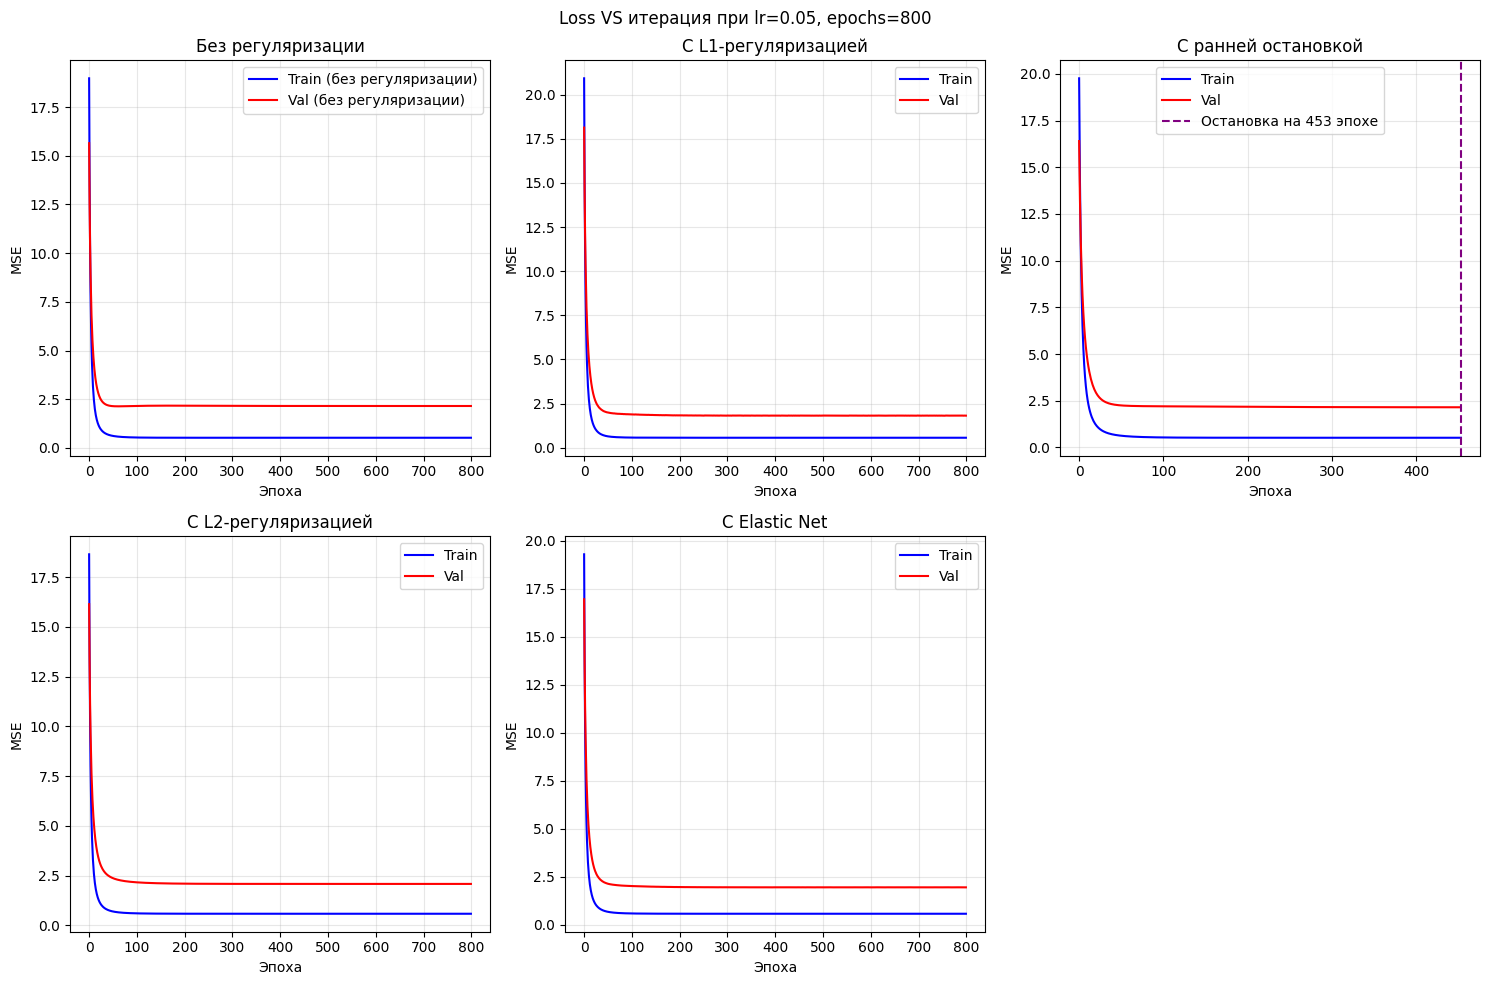

MSE на тестовой выборке без регуляризации: 1.5828
MSE на тестовой выборке с L1-регуляризацией: 1.2798
MSE на тестовой выборке с L2-регуляризацией: 1.4560
MSE на тестовой выборке с ранней остановкой: 1.5838
MSE на тестовой выборке с Elastic Net: 1.3396


In [ ]:
# Построение графиков
plt.figure(figsize=(15, 10))

plt.suptitle("Loss VS итерация при lr=0.05, epochs=800")

plt.subplot(2, 3, 1)
plt.plot(train_losses_no_reg, label='Train (без регуляризации)', color='blue')
plt.plot(val_losses_no_reg, label='Val (без регуляризации)', color='red')
plt.title('Без регуляризации')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(train_losses_l1, label='Train', color='blue')
plt.plot(val_losses_l1, label='Val', color='red')
plt.title('С L1-регуляризацией')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(train_stop, label='Train', color='blue')
plt.plot(val_stop, label='Val', color='red')
plt.axvline(x=stop_epoch, color='purple', linestyle='--', label=f'Остановка на {stop_epoch} эпохе')
plt.title('С ранней остановкой')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4)
plt.plot(train_losses_l2, label='Train', color='blue')
plt.plot(val_losses_l2, label='Val', color='red')
plt.title('С L2-регуляризацией')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(train_losses_elastic, label='Train', color='blue')
plt.plot(val_losses_elastic, label='Val', color='red')
plt.title('С Elastic Net')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE на тестовой выборке без регуляризации: {test_no_reg:.4f}")
print(f"MSE на тестовой выборке с L1-регуляризацией: {test_loss_l1:.4f}")
print(f"MSE на тестовой выборке с L2-регуляризацией: {test_loss_l2:.4f}")
print(f"MSE на тестовой выборке с ранней остановкой: {test_stop:.4f}")
print(f"MSE на тестовой выборке с Elastic Net: {test_elastic:.4f}")

Для данного набора данных наиболее эффективно себя продемонстрировала L1-регуляризация. В исходных данных было 50 признаков, поэтому ее применение позволило нам повысить интерпретируемость модели, приведя к разреженности весов по некоторым признакам. L1-регуляризация достигла разреженности 20%, что значительно выше, чем у других методов и наиболее близкое приближение к исходной разреженности весов (60%). В результате удалось достигнуть наименьшего значения test MSE. При этом норма стала чуть меньше исходной, что подвтерждает зануление весов по неважным признакам.

L2 регуляризация "сжала" веса, не обнуляя их (на что указывает самая минимальная норма среди рассматриваемых). При этом снижение MSE не так заметно как при L1-регуляризации. Разреженность при этом осталась ожидаемо низкая (2%)

Elastic Net - золотая середина между всеми рассматриваемыми методами. Она также привела к снижению MSE (на втором месте по эффективности после L1-регуляризации), не приводя при этом к высокой разреженности весов (8%).

Ранняя остановка на данном наборе данных показала такое же значение по MSE, как и обучение без регуляризации, приведя при этом к меньшей разреженности весов (6%).

Таким образом, на практике самым оптимальным решением может быть комбинирование нескольких методов регуляризации. L1-регуляризация повышает интерпретируемость модели, приводя к разреженности весов, что может быть полезно для выявления наиболее важных признаков. L2-регуляризация позволяет сохранить веса модели, повышая устойчивость модели и давая более гладкое распределение весов. Если же необходим баланс между устойчивостью и точностью, можно воспользоваться Elastic Net, самостоятельно регулируя степень влияения L1 и L2 регуляризатора. На примере рассмотренного набора данных Early Stopping оказался эффективным с точки зрения экономии вычислительных ресурсов, так как построенная модель не была склонна к переобучению.

---